# Notebook for running basic sanity checks on the DFT results

In [1]:
import os
import re
import copy
import numpy as np
import glob
import sys
import ase

import rmgpy.chemkin
import rmgpy.kinetics
import rmgpy.tools.uncertainty


import arkane.modelchem
import arkane.ess
import arkane.encorr
import arkane.common

DFT_DIR = os.path.join(os.environ['AUTOSCIENCE_REPO'], 'dft')
sys.path.append(DFT_DIR)
import autotst_wrapper

sys.path.append(os.environ['DATABASE_DIR'])
import database_fun


import matplotlib.pyplot as plt
%matplotlib inline

/home/harris.se/rmg/RMG-Py/rmgpy/rmg/reactors.py:53: RuntimeWarning: Unable to import Julia dependencies, original error: [Errno 2] No such file or directory: 'julia': 'julia'
  warnings.warn("Unable to import Julia dependencies, original error: " + str(e), RuntimeWarning)


Loading DFT database from /work/westgroup/harris.se/autoscience/reaction_calculator/database


In [3]:
def get_i_thing(thing, thing_list, pdep_specific=False):
    if not pdep_specific:
        for i in range(len(thing_list)):
            if thing.is_isomorphic(thing_list[i]):
                return i
        return -1
    
    for i in range(len(thing_list)):
        if thing.is_isomorphic(thing_list[i]):
            if (isinstance(thing, rmgpy.rmg.pdep.PDepReaction) and isinstance(thing_list[i], rmgpy.rmg.pdep.PDepReaction)) or \
                    (not isinstance(thing, rmgpy.rmg.pdep.PDepReaction) and not isinstance(thing_list[i], rmgpy.rmg.pdep.PDepReaction)):
                return i
    return -1

def get_reaction_species(reaction):
    if type(reaction) == int:
        reaction = database_fun.index2reaction(reaction)
        
    reaction_string = database_fun.get_unique_string(reaction)
    tokens = reaction_string.split('=')
    reactants = [int(i) for i in tokens[0].split('+')]
    products = [int(i) for i in tokens[-1].split('+')]
    return reactants + products

def get_reverse_reaction(reaction):
    assert reaction.kinetics is not None
    rev_reaction = copy.deepcopy(reaction)
    tmp_reactants = rev_reaction.reactants
    rev_reaction.reactants = rev_reaction.products
    rev_reaction.products = tmp_reactants
    rev_reaction.kinetics = reaction.generate_reverse_rate_coefficient()
    return rev_reaction

def reactions_in_same_direction(reaction1, reaction2):
    assert reaction1.is_isomorphic(reaction2), f'Reactions are not even isomorphic {reaction1} {reaction2}'
    if len(reaction1.reactants) != len(reaction2.reactants):
        return False
    reactants_to_match = [r for r in reaction1.reactants]
    counter = 0
    while reactants_to_match:
        for i in range(len(reaction2.reactants)):
            if reaction2.reactants[i].is_isomorphic(reactants_to_match[0]):
                reactants_to_match.remove(reactants_to_match[0])
                break
        else:
            return False
        
        
        if counter >= len(reaction1.reactants):
            return False
        counter += 1
        
    return True


def plot_kinetics(rxns, labels=None, title=None):
    """Function for plotting reaction kinetics
    Takes in a list of RMG reactions (rmgpy.reaction.Reaction) or a single reaction
    """
    plt.xlabel('1000 / T (K^-1)')
    plt.ylabel('log10(k)')
    linestyles = ['solid', 'solid', 'dashed', 'dashed']
    if type(rxns) != list:
        rxns = [rxns]

    T = np.linspace(300, 3000, 1001)
    for m, rxn in enumerate(rxns):
        k = np.zeros(len(T))
        for i in range(0, len(T)):
            k[i] = rxn.get_rate_coefficient(T[i], 101325)
        plt.plot(1000.0 / T, np.log10(k), linestyle=linestyles[m % len(linestyles)])

    if labels:
        plt.legend(labels)
    if title:
        plt.title(title)
    plt.ylim([-10, 10])
    plt.show()

In [4]:
get_reaction_species(4721)

[19, 57, 4, 5]

## Load all of the calculations

In [26]:
# load the calculations
# gather all of the calculations
thermo_libs = glob.glob(os.path.join(DFT_DIR, 'thermo', 'species*', 'arkane', 'RMG_libraries'))
backup_thermo_libs = glob.glob(os.path.join(DFT_DIR, 'thermo', 'backup_*', 'arkane', 'RMG_libraries'))
# Load the Arkane thermo
entries = []
for i, lib_path in enumerate(thermo_libs):
    matches = re.search('species_([0-9]{4})', lib_path)
    species_index = int(matches[1])
    ark_thermo_database = rmgpy.data.thermo.ThermoDatabase()
    ark_thermo_database.load_libraries(
        lib_path,
    )

    for key in ark_thermo_database.libraries['thermo'].entries.keys():
        entry = ark_thermo_database.libraries['thermo'].entries[key]
        entry.index = species_index
        entry.label = entry.item.smiles
        entries.append(entry)
print(f'{len(entries)} thermo entries')

# for i, lib_path in enumerate(backup_thermo_libs):
#     matches = re.search('backup_([0-9]{4})', lib_path)
#     species_index = int(matches[1])
#     ark_thermo_database = rmgpy.data.thermo.ThermoDatabase()
#     ark_thermo_database.load_libraries(
#         lib_path,
#     )

#     for key in ark_thermo_database.libraries['thermo'].entries.keys():
#         entry = ark_thermo_database.libraries['thermo'].entries[key]
#         entry.index = species_index
#         entry.label = entry.item.smiles
#         entries.append(entry)
# print(f'{len(entries)} backup thermo entries')



sp_entries = [e.item for e in entries]


# first, get valid kinetics from old workflow
kinetics_libs = glob.glob(os.path.join(DFT_DIR, 'kinetics', 'reaction*', 'arkane', 'RMG_libraries'))
backup_kinetics_libs = glob.glob(os.path.join(DFT_DIR, 'kinetics', 'reaction*', 'backup_arkane*', 'RMG_libraries'))

# Load the Arkane kinetics
k_entries = []
for i, lib_path in enumerate(kinetics_libs):
    matches = re.search('reaction_([0-9]{4,6})', lib_path)
    reaction_index = int(matches[1])
    
    ark_kinetics_database = rmgpy.data.kinetics.KineticsDatabase()
    ark_kinetics_database.load_libraries(lib_path)
    
    
    # TODO fix bug related to load_libraries not getting the actual name
    for key in ark_kinetics_database.libraries[''].entries.keys():
        entry = ark_kinetics_database.libraries[''].entries[key]
        
        
        # check isomorphism with include_list
        idx = database_fun.get_unique_reaction_index(ark_kinetics_database.libraries[''].entries[key].item)

        entry.index = reaction_index
        k_entries.append(entry)
#         print(f'Adding\t{entry.index}\t{entry}')
print(f'{len(k_entries)} kinetics entries')


# for i, lib_path in enumerate(backup_kinetics_libs):
#     matches = re.search('reaction_([0-9]{4,6})', lib_path)
#     reaction_index = int(matches[1])
    
#     ark_kinetics_database = rmgpy.data.kinetics.KineticsDatabase()
#     ark_kinetics_database.load_libraries(lib_path)
    
    
#     # TODO fix bug related to load_libraries not getting the actual name
#     for key in ark_kinetics_database.libraries[''].entries.keys():
#         entry = ark_kinetics_database.libraries[''].entries[key]
        
        
#         # check isomorphism with include_list
#         idx = database_fun.get_unique_reaction_index(ark_kinetics_database.libraries[''].entries[key].item)

#         entry.index = reaction_index
#         k_entries.append(entry)
# #         print(f'Adding\t{entry.index}\t{entry}')
# print(f'{len(k_entries)} backup kinetics entries')

rxn_entries = [e.item for e in k_entries]

96 thermo entries
42 kinetics entries


## 1. Compare results to other methods

### 1.1 Do single point energies with AE corrections differ by more than 3.35 kcal/mol between m06-2x and dlpno-CCSD(T)?

In [27]:
species_files = glob.glob(os.path.join(DFT_DIR, 'thermo', f'species_*', 'arkane', 'RMG_libraries', 'thermo.py'))
species_indices = [autotst_wrapper.get_species_index_from_path(s) for s in species_files]

errs = []
cc_e_elec = []
m06_e_elec = []
sps = []

for i in species_indices:
    orca_file = os.path.join(DFT_DIR, 'thermo', f'species_{i:04}', 'arkane', 'conformer.out')
    if not os.path.exists(orca_file):
        continue
    
    try:
        gaussian_file = glob.glob(os.path.join(DFT_DIR, 'thermo', f'species_{i:04}', 'arkane', 'conformer_*.log'))[0]
    except IndexError:
        continue
        
    ol = arkane.ess.ess_factory(orca_file)
    gl = arkane.ess.ess_factory(gaussian_file)
    coord, number, mass = gl.load_geometry()
    cf = gl.load_conformer()
    
    zpe_scale_factor = 0.9418145956607494
    gl_energy = gl.load_energy(zpe_scale_factor)
    ol_energy = ol.load_energy(zpe_scale_factor)
    
    
    # Infer atoms from geometry
    atoms = {}
    for atom_num in number:
        try:
            symbol = arkane.common.symbol_by_number[atom_num]
        except KeyError:
            raise ElementError('Could not recognize element number {0}.'.format(atom_num))
        atoms[symbol] = atoms.get(symbol, 0) + 1
    m06 = arkane.modelchem.LevelOfTheory(method='m062x', basis='ccpvtz', software='gaussian')
    cc = arkane.modelchem.CompositeLevelOfTheory(
        freq=arkane.modelchem.LevelOfTheory(method='m062x', basis='ccpvtz', software='gaussian'),
        energy=arkane.modelchem.LevelOfTheory(method='dlpnoccsd(t)f122023', basis='ccpvtzf12', software='orca')
    )
    
    
    g_atom_corrections = arkane.encorr.corr.get_atom_correction(m06, atoms)
    o_atom_corrections = arkane.encorr.corr.get_atom_correction(cc, atoms)
    
    
    cc_e_elec_corr = ol_energy + o_atom_corrections
    m06_e_elec_corr = gl_energy + g_atom_corrections
    
    pct_err = (cc_e_elec_corr - m06_e_elec_corr) / m06_e_elec_corr * 100
    err_kcal = (cc_e_elec_corr - m06_e_elec_corr) / 4184
    
    cc_e_elec.append(cc_e_elec_corr)
    m06_e_elec.append(m06_e_elec_corr)
    errs.append(err_kcal)
    sps.append(i)
#     if np.abs(err_kcal) > 10:
#         print(f'Species {i} with multiplicity {multiplicity} has error {pct_err:.3f}%, {err_kcal:.3f} kcal/mol')
#     break

In [5]:
THRESHOLD = 3.35
for i in range(len(errs)):
    if errs[i] > THRESHOLD:
        print(sps[i], errs[i])

90 3.9316781497138407
271 12.270961822760265
543 4.548231157472439


In [6]:
# Now do reactions

reaction_files = glob.glob(os.path.join(DFT_DIR, 'kinetics', f'reaction_*', 'arkane', 'RMG_libraries', 'reactions.py'))
reaction_indices = [autotst_wrapper.get_reaction_index_from_path(r) for r in reaction_files]

errs = []
cc_e_elec = []
m06_e_elec = []
sps = []

for i in reaction_indices:
    orca_file = os.path.join(DFT_DIR, 'kinetics', f'reaction_{i:06}', 'arkane', 'ts', 'conformer.out')
    if not os.path.exists(orca_file):
        continue
    
    try:
        gaussian_file = glob.glob(os.path.join(DFT_DIR, 'kinetics', f'reaction_{i:06}', 'arkane', 'ts', 'fwd_ts_*.log'))[0]
    except IndexError:
        continue
        
    ol = arkane.ess.ess_factory(orca_file)
    gl = arkane.ess.ess_factory(gaussian_file)
    coord, number, mass = gl.load_geometry()
    cf = gl.load_conformer()
    
    zpe_scale_factor = 0.9418145956607494
    gl_energy = gl.load_energy(zpe_scale_factor)
    ol_energy = ol.load_energy(zpe_scale_factor)
    
    
    # Infer atoms from geometry
    atoms = {}
    for atom_num in number:
        try:
            symbol = arkane.common.symbol_by_number[atom_num]
        except KeyError:
            raise ElementError('Could not recognize element number {0}.'.format(atom_num))
        atoms[symbol] = atoms.get(symbol, 0) + 1
    m06 = arkane.modelchem.LevelOfTheory(method='m062x', basis='ccpvtz', software='gaussian')
    cc = arkane.modelchem.CompositeLevelOfTheory(
        freq=arkane.modelchem.LevelOfTheory(method='m062x', basis='ccpvtz', software='gaussian'),
        energy=arkane.modelchem.LevelOfTheory(method='dlpnoccsd(t)f122023', basis='ccpvtzf12', software='orca')
    )
    
    
    g_atom_corrections = arkane.encorr.corr.get_atom_correction(m06, atoms)
    o_atom_corrections = arkane.encorr.corr.get_atom_correction(cc, atoms)
    
    
    cc_e_elec_corr = ol_energy + o_atom_corrections
    m06_e_elec_corr = gl_energy + g_atom_corrections
    
    pct_err = (cc_e_elec_corr - m06_e_elec_corr) / m06_e_elec_corr * 100
    err_kcal = (cc_e_elec_corr - m06_e_elec_corr) / 4184
    
    cc_e_elec.append(cc_e_elec_corr)
    m06_e_elec.append(m06_e_elec_corr)
    errs.append(err_kcal)
    sps.append(i)


In [7]:
THRESHOLD = 1.5
for i in range(len(errs)):
    if errs[i] > THRESHOLD:
        print(sps[i], errs[i])

52 3.7828921224373477
324 5.295589277552829
419 2.4418842123525777
804 1.954185237278218
808 1.5785007129777686
1111 2.027378371409203
4796 4.908773502302899


In [8]:
np.sqrt(np.float_power(3.0, 2) + np.float_power(1.5, 2))  # uncertainties of m06-2x and dlpno-CCSD(T) added in quadrature

3.3541019662496847

### 1.2. Do any of the species thermodynamics differ by more than the GAV + dlpno-CCSD(T) uncertainty?

In [9]:
# Need to load a thermo database to get GAV
database = rmgpy.data.rmg.RMGDatabase()

thermo_libraries = [
    'BurkeH2O2',
    'primaryThermoLibrary',
]

database.load(
    path = rmgpy.settings['database.directory'],
    thermo_libraries = thermo_libraries,
    transport_libraries = [],
    reaction_libraries = [],
    seed_mechanisms = [],
    kinetics_families = 'default',
    kinetics_depositories = [],
    depository = False,
)

In [10]:
# Get all species GAV uncertainties
GAV_species = [rmgpy.species.Species(molecule=[entry.item]) for entry in entries]
for i in range(len(GAV_species)):
    GAV_species[i].thermo = database.thermo.get_thermo_data(GAV_species[i])

uncertainty = rmgpy.tools.uncertainty.Uncertainty(species_list=GAV_species, reaction_list=[])
uncertainty.database = database

uncertainty.extract_sources_from_model()
uncertainty.assign_parameter_uncertainties()

GAV_uncertainties = uncertainty.thermo_input_uncertainties
    

In [11]:
beyond_uncertainty = []
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
alpha = 0.65
U_DFT = 1.5
DFT_95 = U_DFT * 1.96
plot = False
for i, thermo_entry in enumerate(entries):
    species_index = thermo_entry.index

    U_GAV = GAV_uncertainties[i]
    GAV_95 = U_GAV * 1.96
    
    Ts = np.linspace(300, 1500, 11)
#     Ts = np.linspace(1000, 1100, 11)
    Gs_GAV = np.zeros_like(Ts)
    Gs_DFT = np.zeros_like(Ts)
    for j in range(len(Ts)):
        Gs_GAV[j] = GAV_species[i].get_free_energy(Ts[j]) / 4184  # kcal/mol
        Gs_DFT[j] = thermo_entry.data.get_free_energy(Ts[j]) / 4184  # kcal/mol
        
        
    MAX_DIFF_U_std = np.sqrt(np.float_power(U_DFT, 2.0) + np.float_power(U_GAV, 2.0))
    MAX_DIFF_U_95 = MAX_DIFF_U_std * 1.96  # convert 1 standard deviation of a normal distribution to a 95% interval

    
    if np.any(np.abs(Gs_GAV - Gs_DFT) > MAX_DIFF_U_95):
        beyond_uncertainty.append(species_index)
        
        if plot:
            plt.plot(1000.0 / Ts, Gs_GAV, label='GAV', color=colors[0])
            plt.fill_between(1000.0 / Ts, Gs_GAV, Gs_GAV + GAV_95, alpha=alpha, color=colors[0])
            plt.fill_between(1000.0 / Ts, Gs_GAV, Gs_GAV - GAV_95, alpha=alpha, color=colors[0])


            plt.plot(1000.0 / Ts, Gs_DFT, label='DFT', color=colors[1])
            plt.fill_between(1000.0 / Ts, Gs_DFT, Gs_DFT + DFT_95, alpha=alpha, color=colors[1])
            plt.fill_between(1000.0 / Ts, Gs_DFT, Gs_DFT - DFT_95, alpha=alpha, color=colors[1])

            plt.xlabel('1000 K / T')
            plt.ylabel('Gibbs Energy (kcal / mol)')
            plt.title(f'{species_index}: {thermo_entry.item.smiles} 95% Confidence')
            ax = plt.gca()
            ax.spines['right'].set_visible(False)
            ax.spines['top'].set_visible(False)
            plt.legend()
            plt.show()
    
if beyond_uncertainty:
    print(f'You have {len(beyond_uncertainty)} species outside the GAV + DFT 95% confidence interval:')
    for i in beyond_uncertainty:
        print(f'\t{i}')
else:
    print(f'All species inside the GAV + DFT 95% confidence interval')
    

You have 25 species outside the GAV + DFT 95% confidence interval:
	6
	7
	28
	34
	44
	48
	77
	79
	83
	84
	85
	87
	88
	89
	91
	93
	269
	294
	305
	543
	634
	856
	857
	863
	1113


### 1.3 Do any of the reaction kinetics differ by more than the rate rule + dlpno-CCSD(T) uncertainty?

In [17]:
# Get all reaction rate rule uncertainties
rate_rule_reactions = [copy.deepcopy(entry.item) for entry in k_entries]
rate_rules = [copy.deepcopy(entry.item) for entry in k_entries]
for i in range(len(rate_rule_reactions)):
    for family in database.kinetics.families:
        try:
            r, p = database.kinetics.families[family].get_labeled_reactants_and_products(
                [sp.molecule[0] for sp in rate_rule_reactions[i].reactants],
                [sp.molecule[0] for sp in rate_rule_reactions[i].products]
            )
            if r and p:
                
                new_rxn = rmgpy.data.kinetics.family.TemplateReaction()
                new_rxn.reactants = r
                new_rxn.products = p
                new_rxn.family = family

                for j in range(len(r)):
                    index1 = get_i_thing(r[j], sp_entries)
                    assert index1 >= 0
                    rate_rule_reactions[i].reactants[j].thermo = entries[index1].data
                for j in range(len(p)):
                    index1 = get_i_thing(p[j], sp_entries)
                    assert index1 >= 0
                    rate_rule_reactions[i].products[j].thermo = entries[index1].data

                template_labels = database.kinetics.families[family].get_reaction_template_labels(new_rxn)
                template = database.kinetics.families[family].retrieve_template(template_labels)
                degeneracy = database.kinetics.families[family].calculate_degeneracy(new_rxn)
                kinetics = database.kinetics.families[family].get_kinetics_for_template(template, degeneracy=degeneracy)[0]

                rate_rule_reactions[i].kinetics = kinetics
                rate_rules[i] = copy.deepcopy(new_rxn)
                rate_rules[i].kinetics = kinetics
                
                
        except (rmgpy.exceptions.UndeterminableKineticsError, rmgpy.exceptions.KineticsError, IndexError, ValueError, rmgpy.exceptions.ActionError):
            pass
        
        if not rate_rule_reactions[i].kinetics:
            try:
                database.kinetics.families[family].add_atom_labels_for_reaction(
                    rate_rule_reactions[i], output_with_resonance=True, save_order=False, relabel_atoms=True
                )
                
                new_rxn = rmgpy.data.kinetics.family.TemplateReaction()
                new_rxn.reactants = [r.molecule[0] for r in rate_rule_reactions[i].reactants]
                new_rxn.products = [p.molecule[0] for p in rate_rule_reactions[i].products]
                new_rxn.family = family
                
#                 for j in range(len(new_rxn.reactants)):
#                     index1 = get_i_thing(new_rxn.reactants[j], sp_entries)
#                     assert index1 >= 0
#                     rate_rule_reactions[i].reactants[j].thermo = entries[index1].data
#                 for j in range(len(new_rxn.products)):
#                     index1 = get_i_thing(new_rxn.products[j], sp_entries)
#                     assert index1 >= 0
#                     rate_rule_reactions[i].products[j].thermo = entries[index1].data
                
                
                template_labels = database.kinetics.families[family].get_reaction_template_labels(new_rxn)
                template = database.kinetics.families[family].retrieve_template(template_labels)
                degeneracy = database.kinetics.families[family].calculate_degeneracy(new_rxn)
                kinetics = database.kinetics.families[family].get_kinetics_for_template(template, degeneracy=degeneracy)[0]

                rate_rule_reactions[i].kinetics = kinetics
                rate_rules[i] = copy.deepcopy(new_rxn)
                rate_rules[i].kinetics = kinetics
                    
            except (rmgpy.exceptions.UndeterminableKineticsError, rmgpy.exceptions.KineticsError, rmgpy.exceptions.ActionError, IndexError, ValueError):
                pass
            
            
    assert rate_rule_reactions[i].kinetics, f'Failed to get kinetics for {i}'
    assert rate_rules[i].kinetics, f'Failed to get kinetics for {i}'

NameError: name 'database' is not defined

In [ ]:
all_species = []
for i in range(len(rate_rule_reactions)):
    for j in range(len(rate_rule_reactions[i].reactants)):
        try:
            index = all_species.index(rate_rule_reactions[i].reactants[j])
        except ValueError:
            all_species.append(rate_rule_reactions[i].reactants[j])
    for j in range(len(rate_rule_reactions[i].products)):
        try:
            index = all_species.index(rate_rule_reactions[i].products[j])
        except ValueError:
            all_species.append(rate_rule_reactions[i].products[j])

for i in range(len(all_species)):
    
    if not all_species[i].thermo:
        all_species[i].thermo = rmgpy.thermo.nasa.NASA()
    
    all_species[i].thermo.comment = 'Thermo library: fakeLibrary'

In [ ]:
uncertainty = rmgpy.tools.uncertainty.Uncertainty(species_list=all_species, reaction_list=rate_rules)
uncertainty.database = database

uncertainty.extract_sources_from_model()
uncertainty.assign_parameter_uncertainties()

GAV_uncertainties = uncertainty.thermo_input_uncertainties
rate_rule_uncertainties = uncertainty.kinetic_input_uncertainties

In [ ]:
beyond_uncertainty = []
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
alpha = 0.65
U_DFT = np.log(10.0) / np.sqrt(3)
DFT_95 = U_DFT * 1.96
plot = False
for i, kinetics_entry in enumerate(k_entries):
    reaction_index = kinetics_entry.index

    U_rr = rate_rule_uncertainties[i]
    U_rr_95 = U_rr * 1.96
    
    Ts = np.linspace(300, 1500, 11)
#     Ts = np.linspace(1000, 1100, 11)
    log_ks_rr = np.zeros_like(Ts)
    log_ks_DFT = np.zeros_like(Ts)
    for j in range(len(Ts)):
        log_ks_rr[j] = np.log10(rate_rules[i].get_rate_coefficient(Ts[j]))
        log_ks_DFT[j] = np.log10(kinetics_entry.data.get_rate_coefficient(Ts[j]))
        
        
    MAX_DIFF_U_std = np.sqrt(np.float_power(U_DFT, 2.0) + np.float_power(U_rr, 2.0))
    MAX_DIFF_U_95 = MAX_DIFF_U_std * 1.96  # convert 1 standard deviation of a normal distribution to a 95% interval

    
    if np.any(np.abs(log_ks_rr - log_ks_DFT) > MAX_DIFF_U_95):
        beyond_uncertainty.append(reaction_index)
        
        if plot:
            plt.plot(1000.0 / Ts, log_ks_rr, label='Rate Rule', color=colors[0])
            plt.fill_between(1000.0 / Ts, log_ks_rr, log_ks_rr + np.log10(np.exp(U_rr_95)), alpha=alpha, color=colors[0])
            plt.fill_between(1000.0 / Ts, log_ks_rr, log_ks_rr - np.log10(np.exp(U_rr_95)), alpha=alpha, color=colors[0])


            plt.plot(1000.0 / Ts, log_ks_DFT, label='DFT', color=colors[1])
            plt.fill_between(1000.0 / Ts, log_ks_DFT, log_ks_DFT + np.log10(np.exp(DFT_95)), alpha=alpha, color=colors[1])
            plt.fill_between(1000.0 / Ts, log_ks_DFT, log_ks_DFT - np.log10(np.exp(DFT_95)), alpha=alpha, color=colors[1])

            plt.xlabel('1000 K / T')
            plt.ylabel('log10 (k)')
            plt.title(f'{reaction_index}: {kinetics_entry.label} 95% Confidence')
            ax = plt.gca()
            ax.spines['right'].set_visible(False)
            ax.spines['top'].set_visible(False)
            plt.legend()
            plt.show()
    
if beyond_uncertainty:
    print(f'You have {len(beyond_uncertainty)} reactions outside the rate rule + DFT 95% confidence interval:')
    for i in beyond_uncertainty:
        print(f'\t{i}')
else:
    print(f'All reactions inside rate rule + DFT 95% confidence interval')
    

### Do any of these differ by a lot from Aramco?

In [4]:
chemkin_fileA = '/work/westgroup/harris.se/autoscience/fuels/butane/official/aramco/chem_annotated.inp'
dict_fileA = '/work/westgroup/harris.se/autoscience/fuels/butane/official/aramco/species_dictionary.txt'
species_listA, reaction_listA = rmgpy.chemkin.load_chemkin_file(chemkin_fileA, dict_fileA)

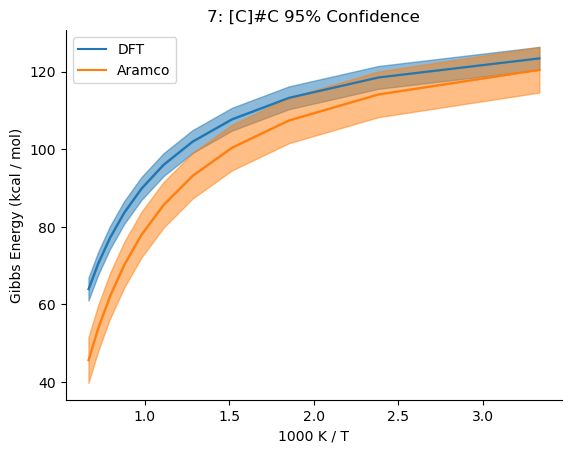

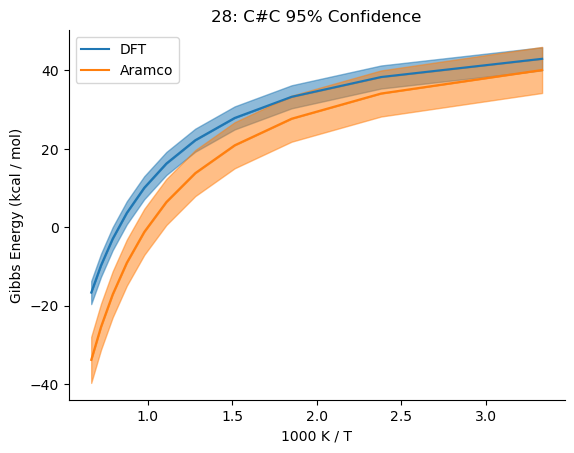

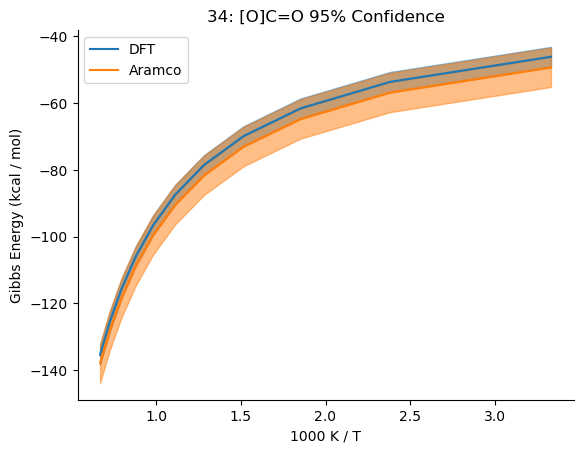

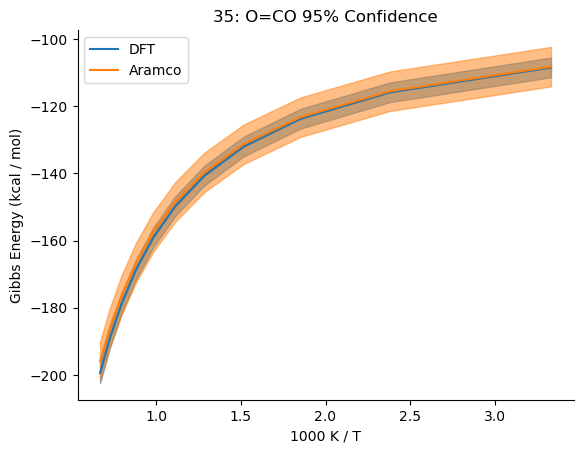

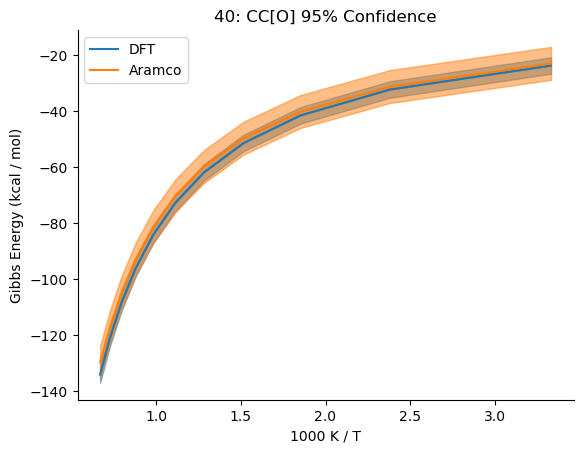

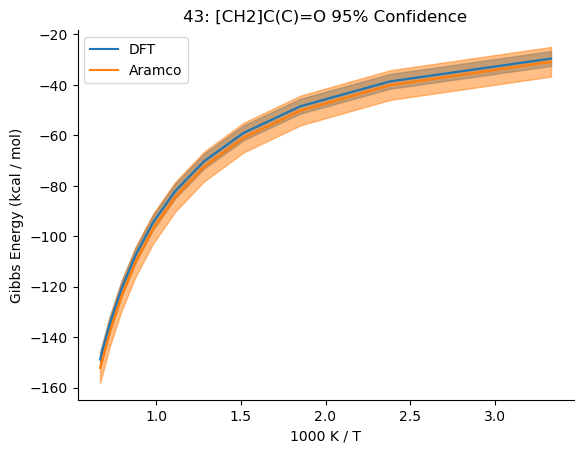

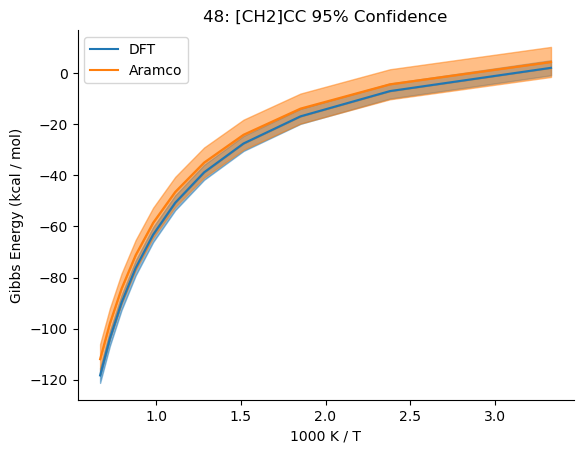

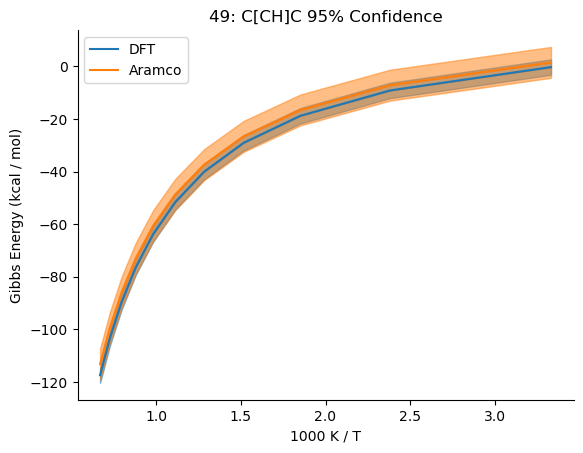

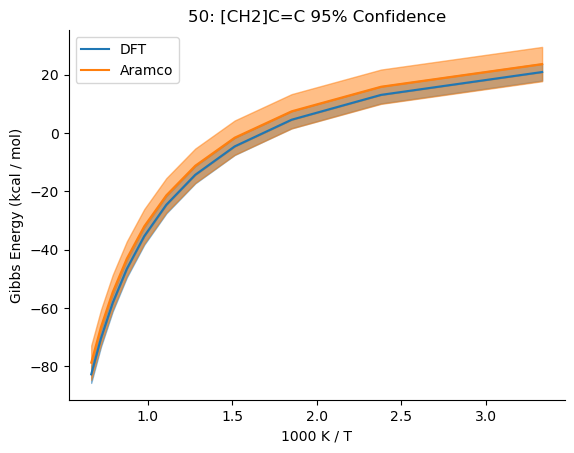

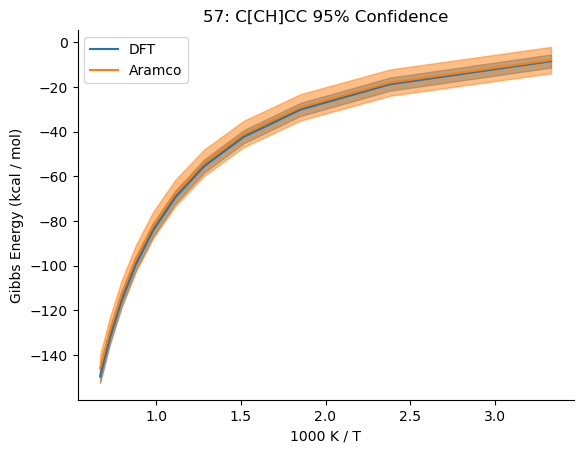

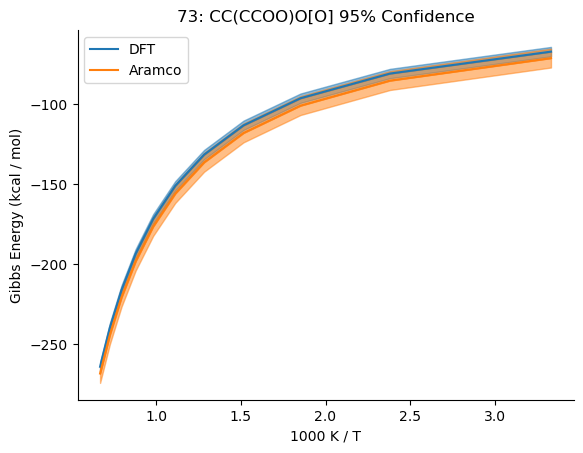

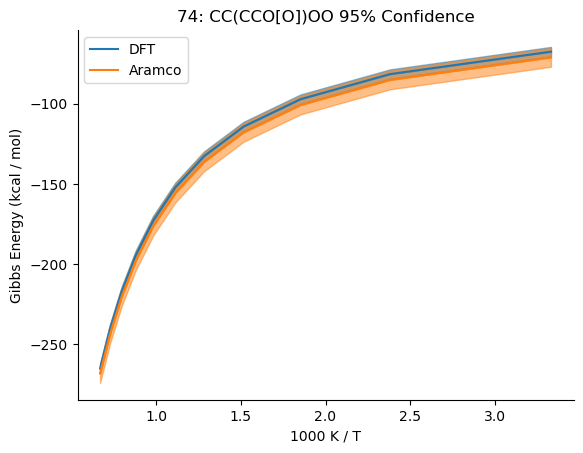

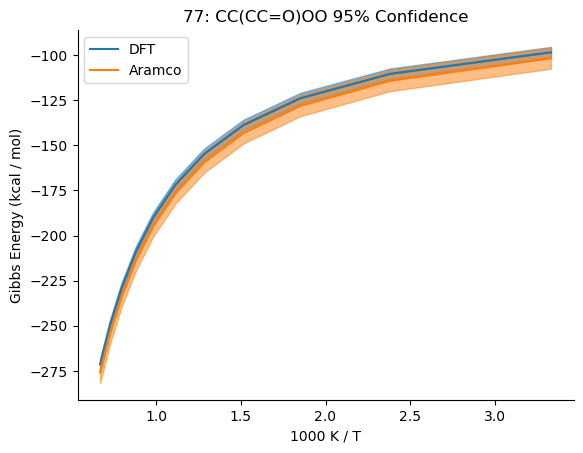

Aramco doesnt have 79
Aramco doesnt have 81
Aramco doesnt have 83
Aramco doesnt have 84
Aramco doesnt have 85
Aramco doesnt have 87
Aramco doesnt have 88
Aramco doesnt have 89
Aramco doesnt have 90
Aramco doesnt have 91
Aramco doesnt have 92
Aramco doesnt have 93
Aramco doesnt have 94
Aramco doesnt have 95
Aramco doesnt have 96
Aramco doesnt have 98
Aramco doesnt have 269
Aramco doesnt have 271
Aramco doesnt have 294


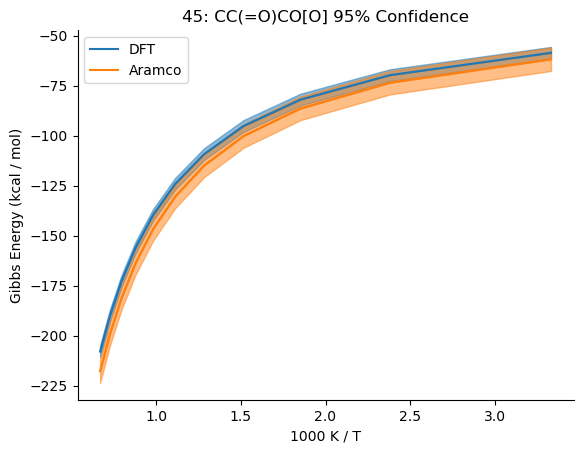

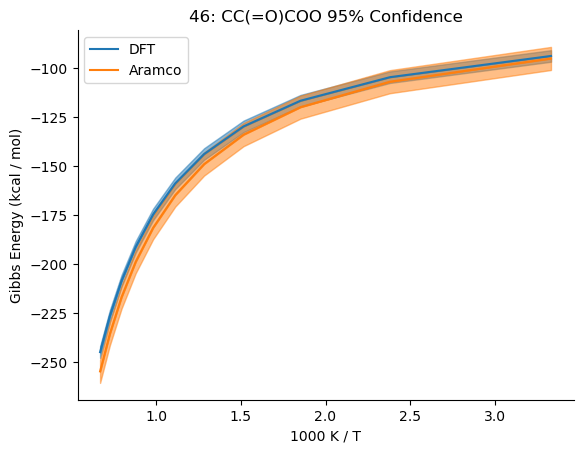

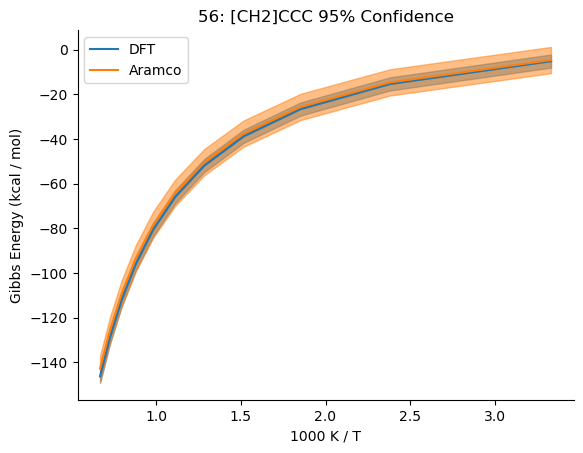

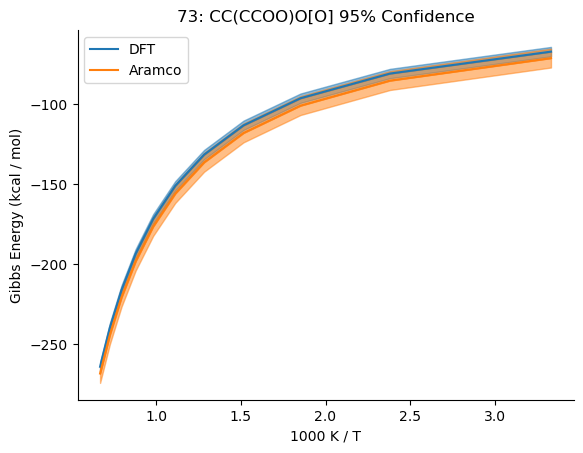

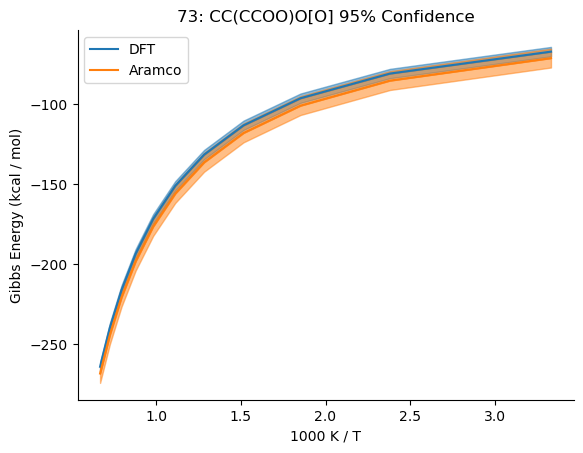

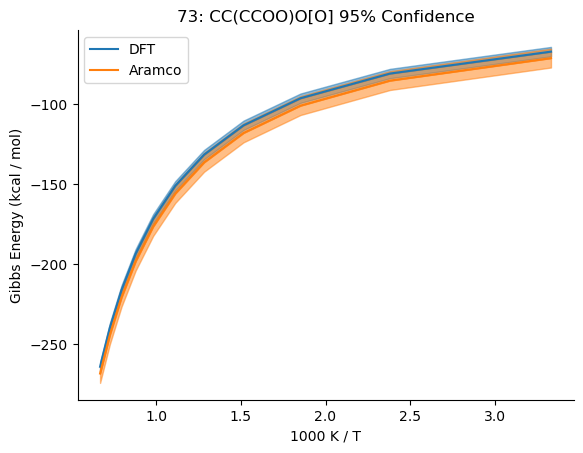

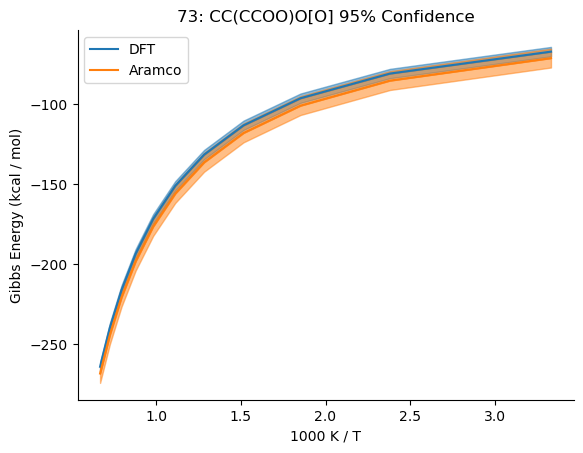

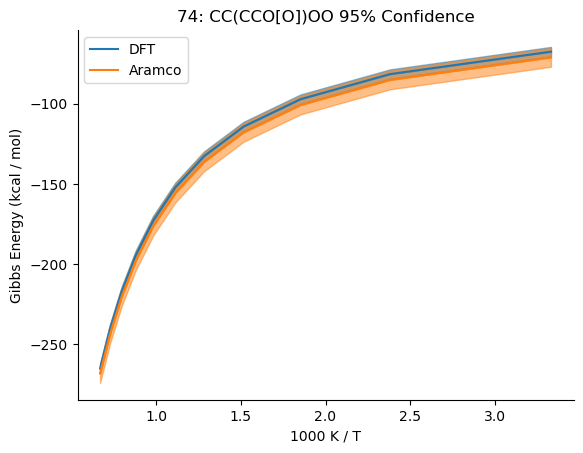

In [15]:
## Look at reactions
aramco_diff = []
U_G_Aramco = 1.5
U_G_Aramco = 3.0
U_Aramco_95 = U_G_Aramco * 1.96
plot = True
U_DFT = 1.5
DFT_95 = U_DFT * 1.96
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
alpha = 0.5
    
for i in [e.index for e in entries]:
    if i > 300:
        continue
#     print(i)
    Ts = np.linspace(300, 1500, 11)
#     Ts = np.linspace(1000, 1300, 11)

    entry = [e for e in entries if e.index == i][0]
    
    ref_sp = rmgpy.species.Species(molecule = [entry.item])
    ref_sp.thermo = entry.data

    indexA = get_i_thing(ref_sp, species_listA)
    if indexA <= 0:
        print(f'Aramco doesnt have {i}')
        continue
    spA = species_listA[indexA]
    
    Gs_aramco = np.array([spA.get_free_energy(T) / 4184 for T in Ts])
    Gs_calc = np.array([ref_sp.get_free_energy(T) / 4184 for T in Ts])
    
    
    
    if np.any(np.abs(Gs_aramco - Gs_calc) > U_G_Aramco):
        aramco_diff.append(i)
    
        if plot:
            plt.plot(1000.0 / Ts, Gs_calc, label='DFT', color=colors[0])
            plt.fill_between(1000.0 / Ts, Gs_calc, Gs_calc + DFT_95 , alpha=alpha, color=colors[0])
            plt.fill_between(1000.0 / Ts, Gs_calc, Gs_calc - DFT_95, alpha=alpha, color=colors[0])


            plt.plot(1000.0 / Ts, Gs_aramco, label='Aramco', color=colors[1])
            plt.fill_between(1000.0 / Ts, Gs_aramco, Gs_aramco + U_Aramco_95, alpha=alpha, color=colors[1])
            plt.fill_between(1000.0 / Ts, Gs_aramco, Gs_aramco - U_Aramco_95, alpha=alpha, color=colors[1])

            plt.xlabel('1000 K / T')
            plt.ylabel('Gibbs Energy (kcal / mol)')
            plt.title(f'{i}: {entry.item.smiles} 95% Confidence')
            ax = plt.gca()
            ax.spines['right'].set_visible(False)
            ax.spines['top'].set_visible(False)
            plt.legend()
            plt.show()

In [ ]:
len(aramco_diff)

52


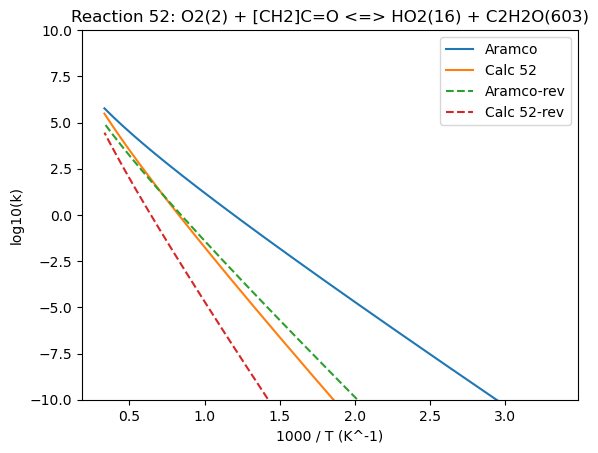

213
Aramco doesnt have 213


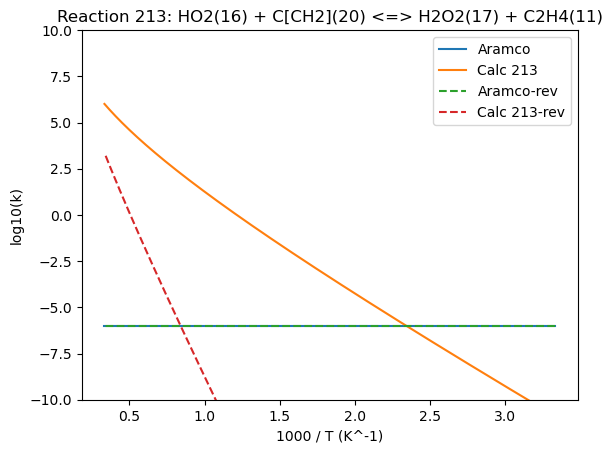

246
253
Aramco doesnt have 253


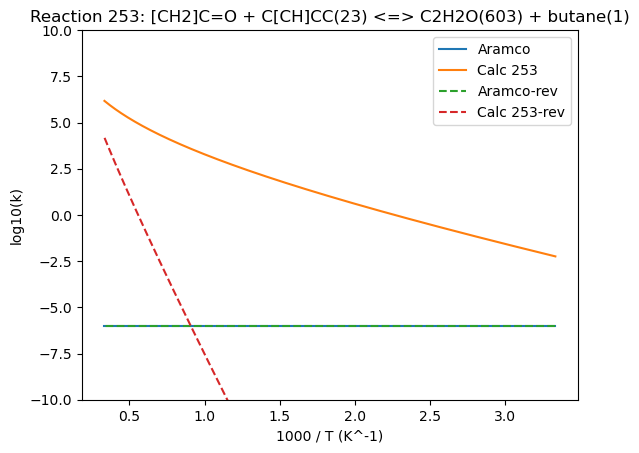

280
Aramco doesnt have 280


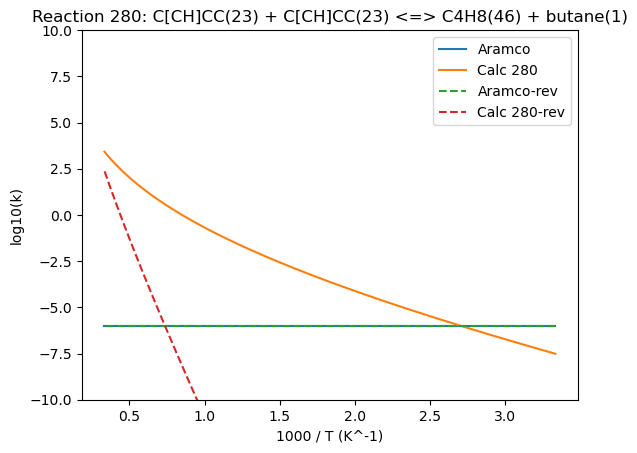

288
296
Aramco doesnt have 296


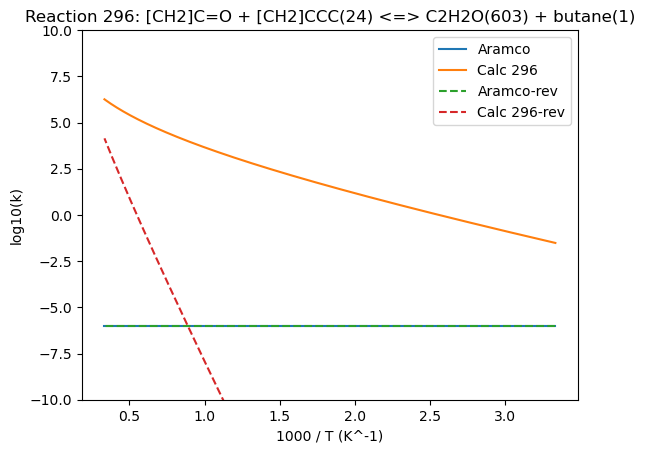

313


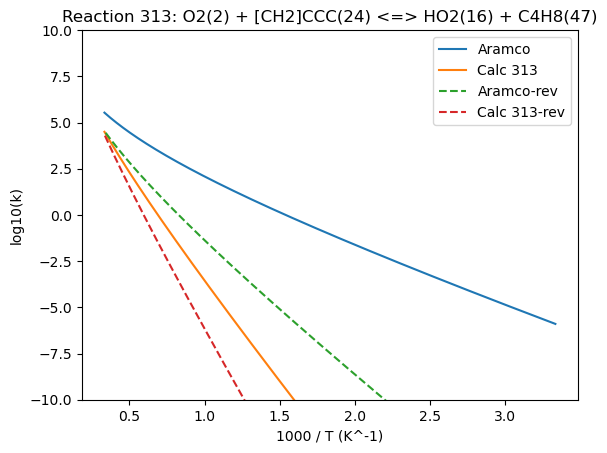

321
Aramco doesnt have 321


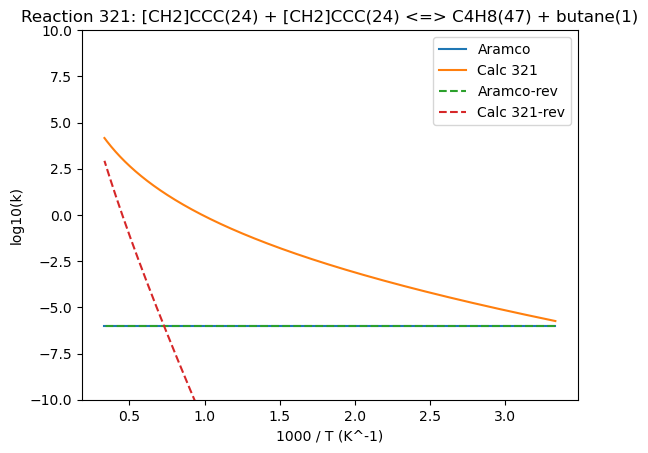

324
Aramco doesnt have 324


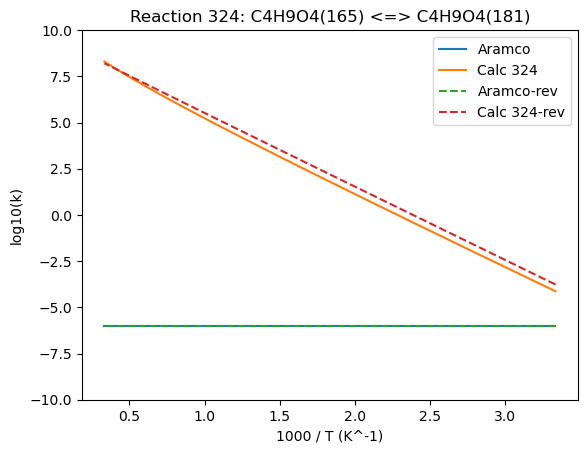

404
Aramco doesnt have 404


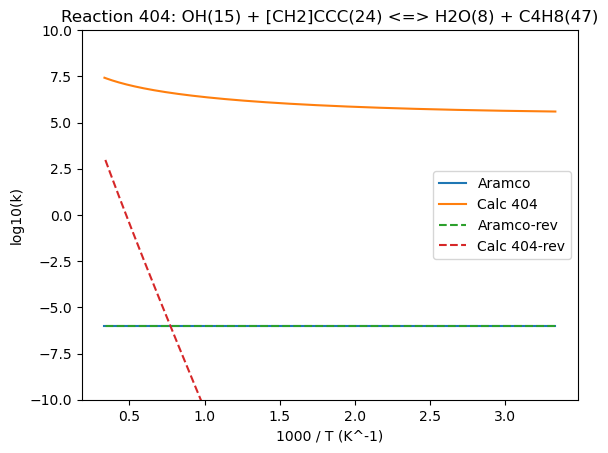

419
Aramco doesnt have 419


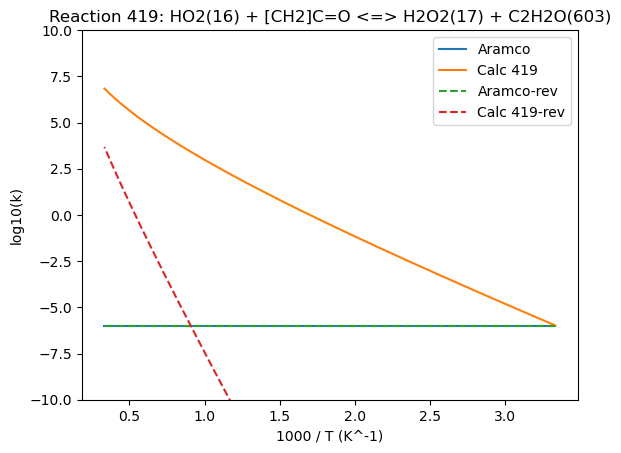

422
Aramco doesnt have 422


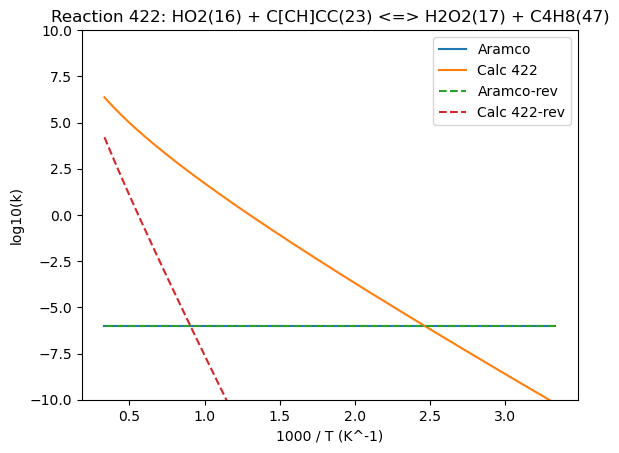

459
Aramco doesnt have 459


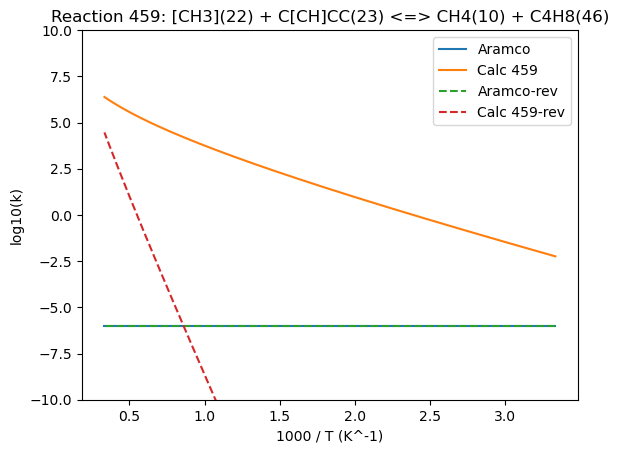

556
586
Aramco doesnt have 586


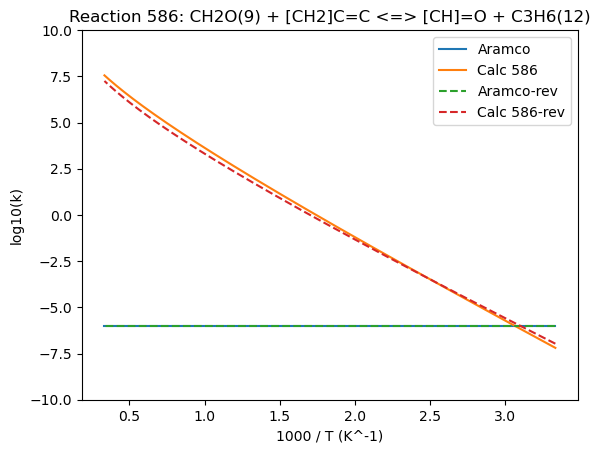

714
Aramco doesnt have 714


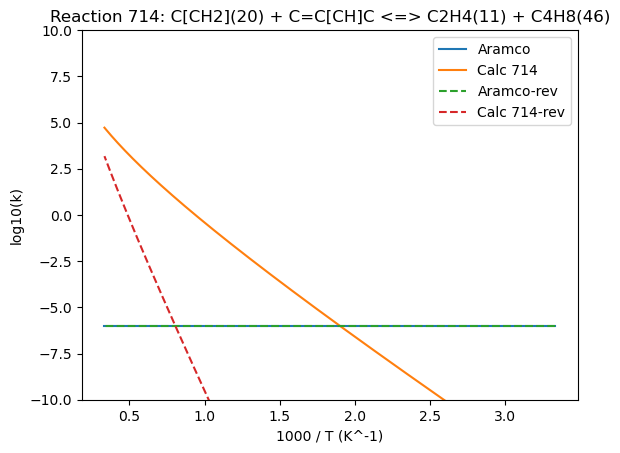

748
Aramco doesnt have 748


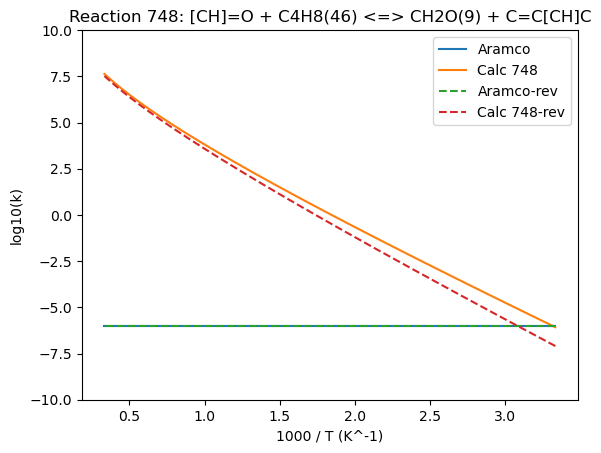

749
Aramco doesnt have 749


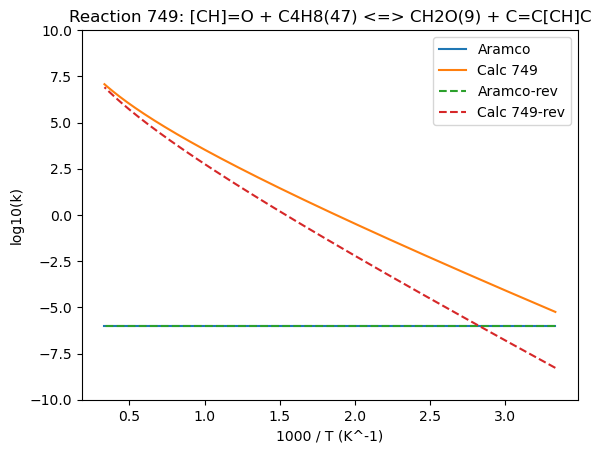

793
Aramco doesnt have 793


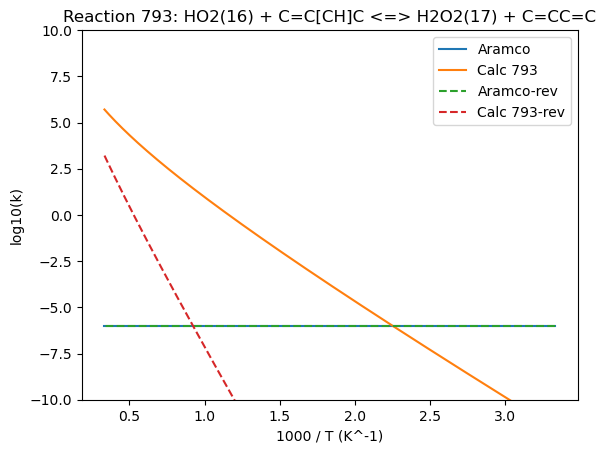

794
Aramco doesnt have 794


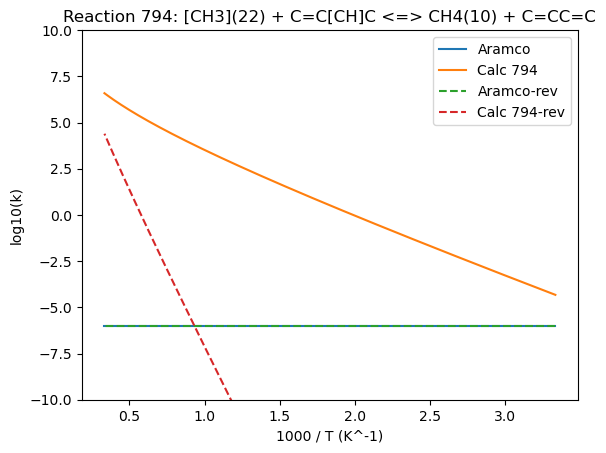

800
Aramco doesnt have 800


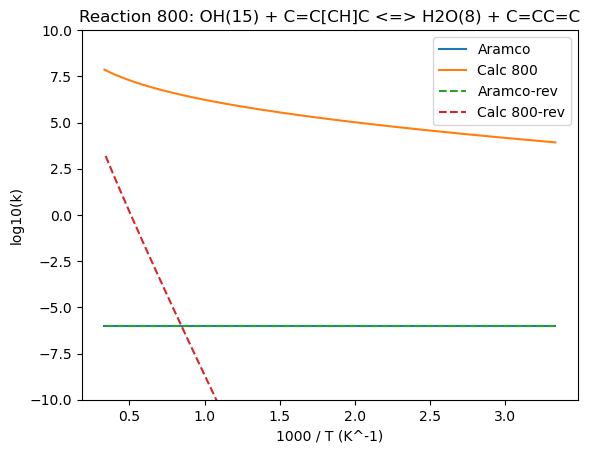

804
Aramco doesnt have 804


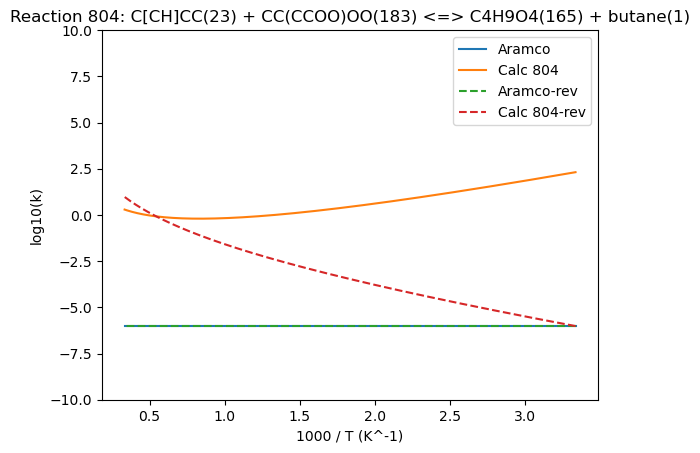

808
Aramco doesnt have 808


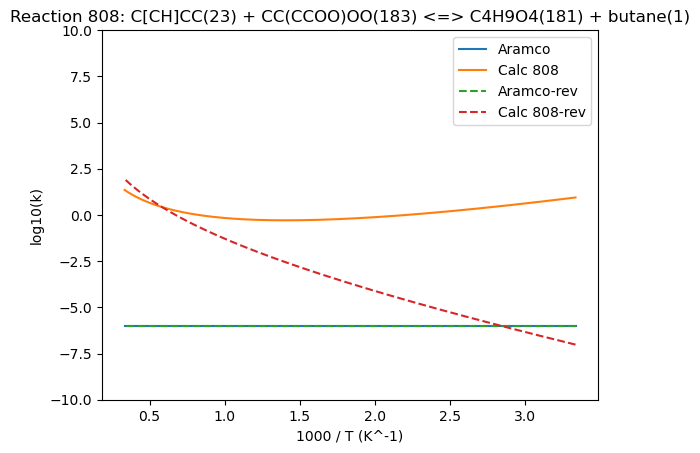

1111
Aramco doesnt have 1111


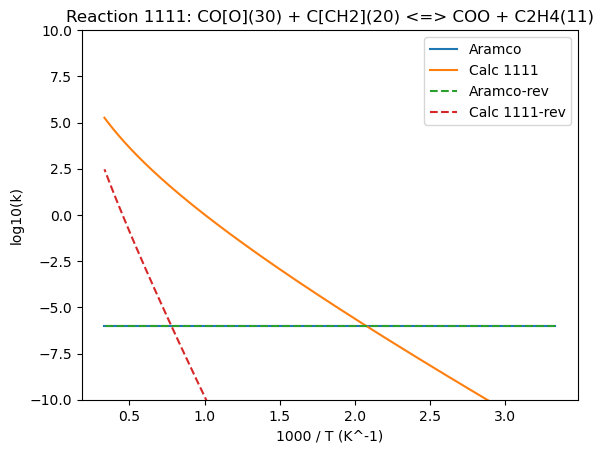

1287
Aramco doesnt have 1287


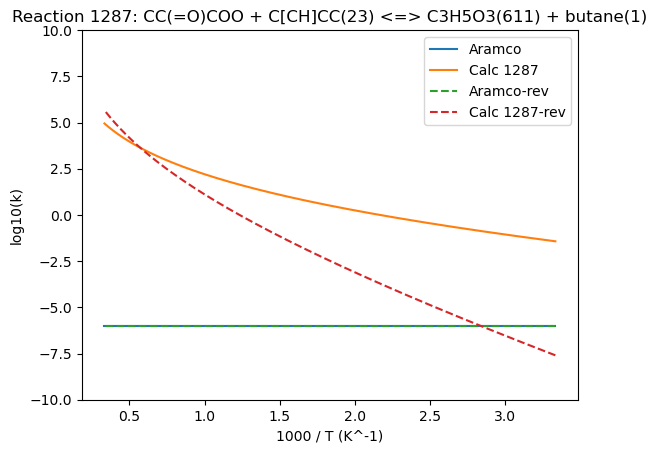

1288
Aramco doesnt have 1288


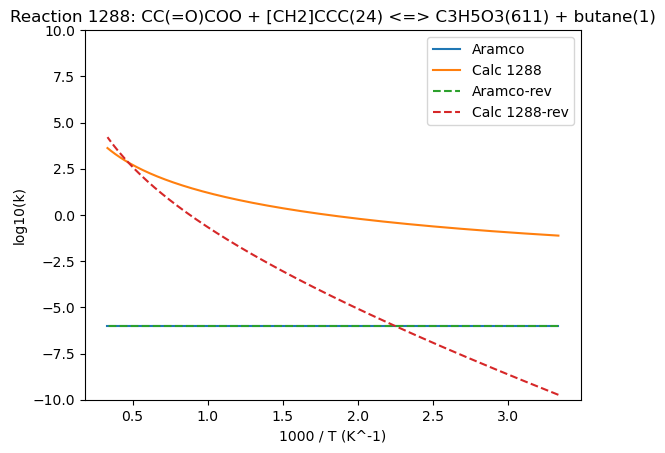

4724
4728
4729
4736
4778


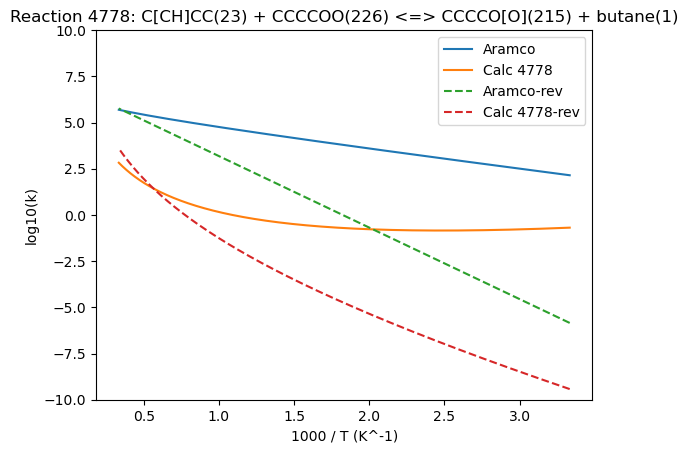

4779


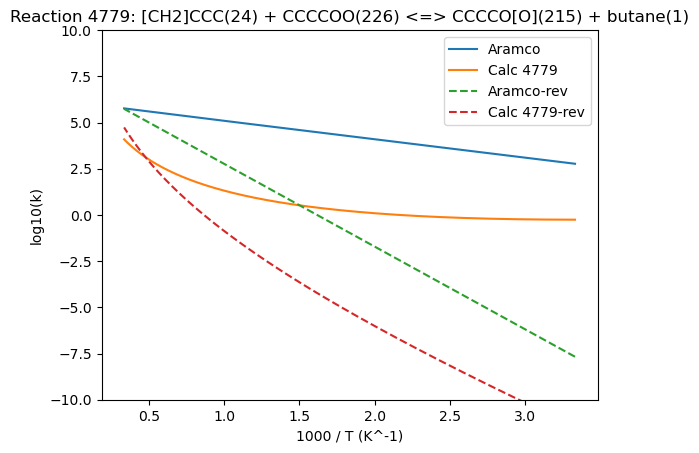

4796
5046
52


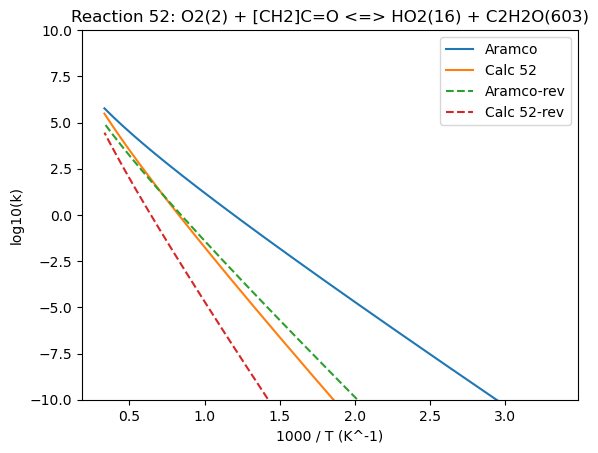

246
278


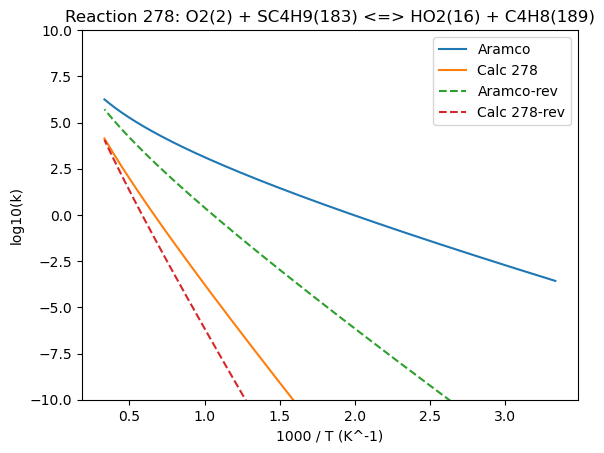

278


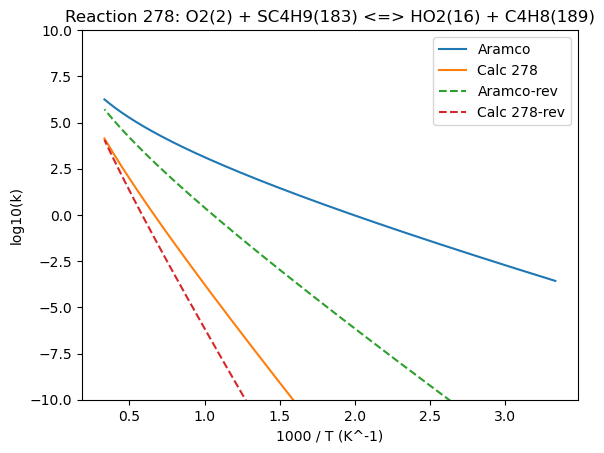

286
286
288
289
289
314


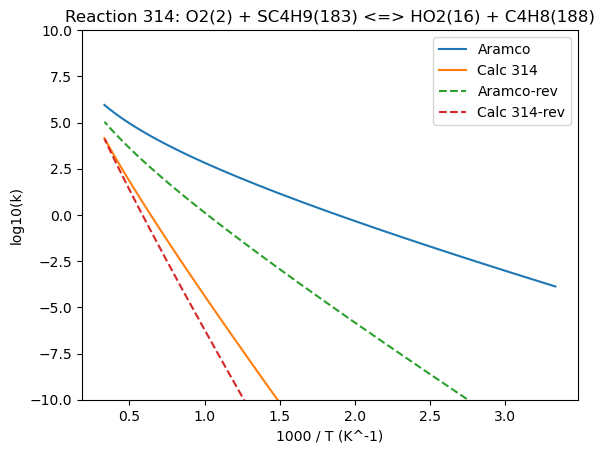

314


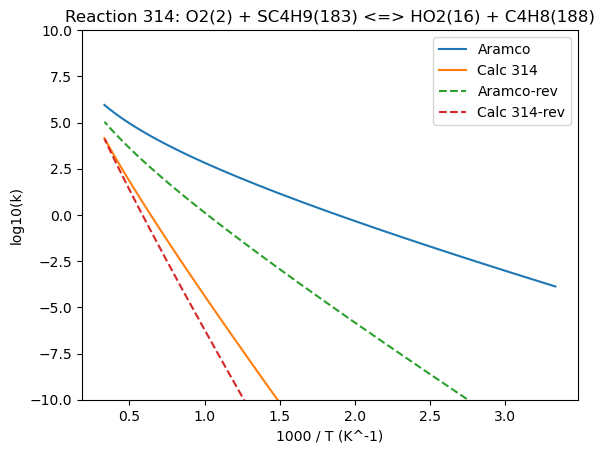

324
Aramco doesnt have 324


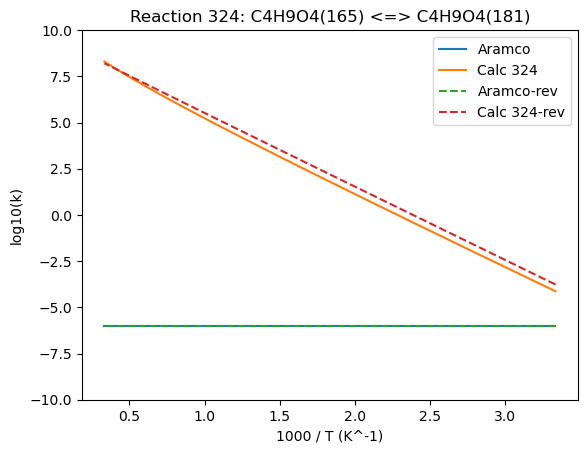

809
Aramco doesnt have 809


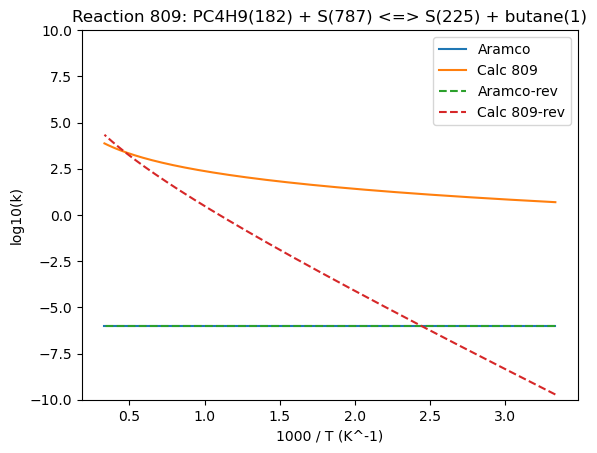

1111
Aramco doesnt have 1111


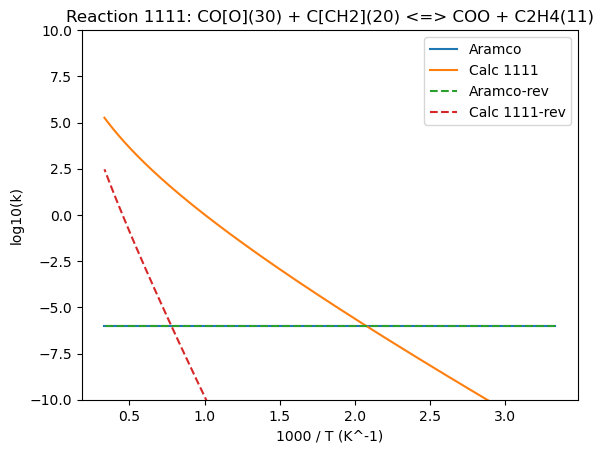

4721


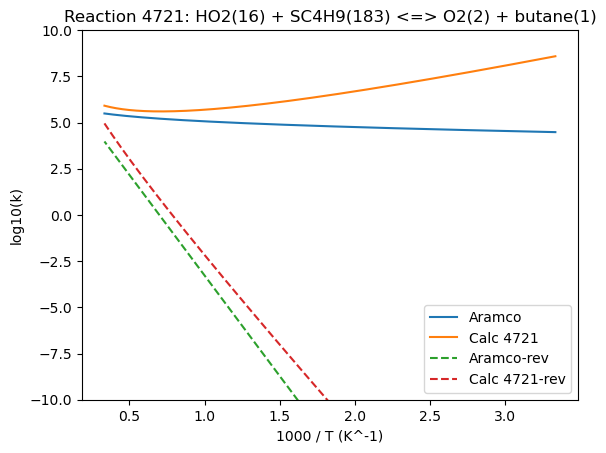

In [18]:
## Look at reactions
aramco_diff = []
U_log10k_Aramco = 4.0
plot = True
# for i in [4779]:
    
for i in [e.index for e in k_entries]:
    if i > 9000:
        continue
    print(i)
    Ts = np.linspace(300, 1500, 11)
    P = 1013250
    entry = [e for e in k_entries if e.index == i][0]
    
    ref_rxn = rmgpy.reaction.Reaction()
    ref_rxn.reactants = entry.item.reactants
    ref_rxn.products = entry.item.products
    ref_rxn.kinetics = entry.data
    for j in range(len(ref_rxn.reactants)):
        index1 = get_i_thing(ref_rxn.reactants[j].molecule[0], sp_entries)
        assert index1 >= 0
        ref_rxn.reactants[j].thermo = entries[index1].data
    
    for j in range(len(ref_rxn.products)):
        index1 = get_i_thing(ref_rxn.products[j].molecule[0], sp_entries)
        assert index1 >= 0
        ref_rxn.products[j].thermo = entries[index1].data
    
    indexA = get_i_thing(entry.item, reaction_listA, pdep_specific=True)
    if indexA <= 0:
        print(f'Aramco doesnt have {i}')
        rxnA = rmgpy.kinetics.Arrhenius(A=(1,'cm^3/(mol*s)'), n=0, Ea=(0.0,'kJ/mol'), T0=(1,'K'), Tmin=(298,'K'), Tmax=(2500,'K'))
        rxnA_rev = rmgpy.kinetics.Arrhenius(A=(1,'cm^3/(mol*s)'), n=0, Ea=(0.0,'kJ/mol'), T0=(1,'K'), Tmin=(298,'K'), Tmax=(2500,'K'))
#         continue
    else:
        rxnA = reaction_listA[indexA]
        if not reactions_in_same_direction(entry.item, rxnA):
            rxnA = get_reverse_reaction(rxnA)
        
        rxnA_rev = get_reverse_reaction(rxnA)
        ks_aramco = [rxnA.get_rate_coefficient(T, P) for T in Ts]
        k_revs_aramco = [rxnA_rev.get_rate_coefficient(T, P) for T in Ts]
        
    ref_rxn_rev = get_reverse_reaction(ref_rxn)
    
    ks_calc = [ref_rxn.get_rate_coefficient(T, P) for T in Ts]
    k_revs_calc = [ref_rxn_rev.get_rate_coefficient(T, P) for T in Ts]
    
    
    if np.any(np.abs(np.log10(np.divide(ks_aramco, ks_calc))) > U_log10k_Aramco) or \
            np.any(np.abs(np.log10(np.divide(k_revs_aramco, k_revs_calc))) > U_log10k_Aramco):
        aramco_diff.append(i)
    
        if plot:
            plot_kinetics([rxnA, ref_rxn, rxnA_rev, ref_rxn_rev], ['Aramco', f'Calc {i}', 'Aramco-rev', f'Calc {i}-rev'], title=f'Reaction {i}: {ref_rxn}')
    if i ==4721:
        break

In [20]:
ref_rxn.kinetics

Arrhenius(A=(1.50279,'cm^3/(mol*s)'), n=3.18743, Ea=(-37.4106,'kJ/mol'), T0=(1,'K'), Tmin=(298,'K'), Tmax=(2500,'K'), comment="""Fitted to 50 data points; dA = *|/ 1.14821, dn = +|- 0.0181572, dEa = +|- 0.0988108 kJ/mol""")

In [21]:
ref_rxn_rev.kinetics

Arrhenius(A=(0.0277859,'m^3/(mol*s)'), n=2.71079, Ea=(167.501,'kJ/mol'), T0=(1,'K'), Tmin=(303.03,'K'), Tmax=(2000,'K'), comment="""Fitted to 29 data points; dA = *|/ 1.05189, dn = +|- 0.00669735, dEa = +|- 0.0350124 kJ/mol""")

In [ ]:
print(aramco_diff)

In [22]:
49 *4.184

205.01600000000002

In [23]:
167/4.184

39.913957934990435

## 2. Check parameter values in reasonable range

In [13]:
my_reactions = []
for i, k in enumerate(k_entries):
    
    r_fwd = rmgpy.reaction.Reaction()
    r_fwd.reactants = k_entries[i].item.reactants
    r_fwd.kinetics = k_entries[i].data
    for j in range(len(r_fwd.reactants)):
        index1 = get_i_thing(r_fwd.reactants[j].molecule[0], sp_entries)
        assert index1 >= 0
        
        r_fwd.reactants[j].thermo = entries[index1].data
    
    
    r_fwd.products = k_entries[i].item.products
    for j in range(len(r_fwd.products)):
        index1 = get_i_thing(r_fwd.products[j].molecule[0], sp_entries)
        assert index1 >= 0
        
        r_fwd.products[j].thermo = entries[index1].data
    
    r_rev = get_reverse_reaction(r_fwd)
    
    
    my_reactions.append([r_fwd, r_rev])

AssertionError: 

### 2.1 Negative reaction barriers?

In [ ]:
T = 1500
negative_reactions = []
negative_reaction_rates = []
for r_fwd, r_rev in my_reactions:
    if r_fwd.kinetics.Ea.value_si <= 1.0 or r_rev.kinetics.Ea.value_si <= 1.0:
        negative_reactions.append(database_fun.get_unique_reaction_index(r_fwd))
        negative_reaction_rates.append(r_fwd)

if negative_reactions:
    print(f'You have {len(negative_reactions)} negative reaction barriers:')
    for i in range(len(negative_reactions)):
        print(f'\t{negative_reactions[i]}:\t{get_reaction_species(negative_reactions[i])}\t\t{np.log10(negative_reaction_rates[i].get_rate_coefficient(T)):.1f}')
else:
    print('All reaction barriers >= 0')

In [ ]:
print(negative_reactions)

In [ ]:
print(database_fun.index2species(57))

In [ ]:
negative_reactions[:-3]

### Draw PES for the Reactions compared to m06-2x

In [ ]:
def get_corrected_energies(gaussian_file, orca_file):
    gl = arkane.ess.ess_factory(gaussian_file)
    ol = arkane.ess.ess_factory(orca_file)
    
    coord, number, mass = gl.load_geometry()
    cf = gl.load_conformer()
    zpe_scale_factor = 0.9418145956607494
    gl_energy = gl.load_energy(zpe_scale_factor)
    ol_energy = ol.load_energy(zpe_scale_factor)
    
    
    # Infer atoms from geometry
    atoms = {}
    for atom_num in number:
        try:
            symbol = arkane.common.symbol_by_number[atom_num]
        except KeyError:
            raise ElementError('Could not recognize element number {0}.'.format(atom_num))
        atoms[symbol] = atoms.get(symbol, 0) + 1
    m06 = arkane.modelchem.LevelOfTheory(method='m062x', basis='ccpvtz', software='gaussian')
    cc = arkane.modelchem.CompositeLevelOfTheory(
        freq=arkane.modelchem.LevelOfTheory(method='m062x', basis='ccpvtz', software='gaussian'),
        energy=arkane.modelchem.LevelOfTheory(method='dlpnoccsd(t)f122023', basis='ccpvtzf12', software='orca')
    )
    
    zpe = gl.load_zero_point_energy() * zpe_scale_factor
    
    g_atom_corrections = arkane.encorr.corr.get_atom_correction(m06, atoms)
    o_atom_corrections = arkane.encorr.corr.get_atom_correction(cc, atoms)
    
    corrected_orca_energy = ol_energy + o_atom_corrections + zpe
    corrected_gaussian_energy = gl_energy + g_atom_corrections + zpe
    
    return corrected_gaussian_energy, corrected_orca_energy

In [ ]:
plot_bar = False

for i in negative_reactions[:-3]:
# for i in [4736]:
    print(i, ':\t', get_reaction_species(i))
    orca_ts_file = os.path.join(DFT_DIR, 'kinetics', f'reaction_{i:06}', 'arkane', 'ts', 'conformer.out')
    gaussian_ts_file = glob.glob(os.path.join(DFT_DIR, 'kinetics', f'reaction_{i:06}', 'arkane', 'ts', 'fwd_ts_*.log'))[0]

    
    r1, r2, p1, p2 = get_reaction_species(i)
    orca_r1_file = os.path.join(DFT_DIR, 'kinetics', f'reaction_{i:06}', 'arkane', f'species_{r1:04}', 'conformer.out')
    gaussian_r1_file = glob.glob(os.path.join(DFT_DIR, 'kinetics', f'reaction_{i:06}', 'arkane', f'species_{r1:04}', 'conformer_*.log'))[0]
    
    orca_r2_file = os.path.join(DFT_DIR, 'kinetics', f'reaction_{i:06}', 'arkane', f'species_{r2:04}', 'conformer.out')
    gaussian_r2_file = glob.glob(os.path.join(DFT_DIR, 'kinetics', f'reaction_{i:06}', 'arkane', f'species_{r2:04}', 'conformer_*.log'))[0]
    
    orca_p1_file = os.path.join(DFT_DIR, 'kinetics', f'reaction_{i:06}', 'arkane', f'species_{p1:04}', 'conformer.out')
    gaussian_p1_file = glob.glob(os.path.join(DFT_DIR, 'kinetics', f'reaction_{i:06}', 'arkane', f'species_{p1:04}', 'conformer_*.log'))[0]
    
    orca_p2_file = os.path.join(DFT_DIR, 'kinetics', f'reaction_{i:06}', 'arkane', f'species_{p2:04}', 'conformer.out')
    gaussian_p2_file = glob.glob(os.path.join(DFT_DIR, 'kinetics', f'reaction_{i:06}', 'arkane', f'species_{p2:04}', 'conformer_*.log'))[0]
    
    g_r1, o_r1 = get_corrected_energies(gaussian_r1_file, orca_r1_file)
    g_r2, o_r2 = get_corrected_energies(gaussian_r2_file, orca_r2_file)
    g_ts, o_ts = get_corrected_energies(gaussian_ts_file, orca_ts_file)
    g_p1, o_p1 = get_corrected_energies(gaussian_p1_file, orca_p1_file)
    g_p2, o_p2 = get_corrected_energies(gaussian_p2_file, orca_p2_file)
    
    gaussian_energies = np.array([g_r1, g_r2, g_ts, g_p1, g_p2]) / 4184
    orca_energies = np.array([o_r1, o_r2, o_ts, o_p1, o_p2]) / 4184
    
    reaction_gaussian_energies = np.array([g_r1 + g_r2, g_ts, g_p1 + g_p2]) / 4184
    reaction_orca_energies = np.array([o_r1 + o_r2, o_ts, o_p1 + o_p2]) / 4184
    labels = ['R1', 'R2', 'TS', 'P1', 'P2']
    
#     x1 = np.arange(5)
#     x2 = np.arange(5) + 0.25
#     plt.scatter(x1, gaussian_energies, label='m06-2x')
#     plt.scatter(x2, orca_energies, label='dlpno-ccsd(t)')
#     plt.legend()
    
    
    if plot_bar:
        levels_of_theory = ['m06-2x', 'dlpno-ccsd(t)']

        width = 0.25  # the width of the bars
        multiplier = 0

        fig, ax = plt.subplots(layout='constrained')

        offset = 0.0
        rects = ax.bar(x + offset, gaussian_energies, width, label=levels_of_theory[0])
        ax.bar_label(rects, padding=2)
        multiplier += 1
        offset = 0.3
        rects = ax.bar(x + offset, orca_energies, width, label=levels_of_theory[1])
        ax.bar_label(rects, padding=2)


        plt.ylabel('Energy (kcal/mol)')
        ax.set_xticks(x + width, labels)
        plt.legend()


        plt.show()
    
    x1 = np.arange(3)
    x2 = np.arange(3)
    plt.plot(x1, reaction_gaussian_energies, label='m06-2x')
    plt.plot(x2, reaction_orca_energies, label='dlpno-ccsd(t)')
    plt.legend()
    plt.show()
    
    


### 2.2 $|n| \geq 4.0$ ?

In [ ]:
large_n = []
N_THRESHOLD = 4.0
for r_fwd, r_rev in my_reactions:
    if np.abs(r_fwd.kinetics.n.value_si) >= N_THRESHOLD or np.abs(r_rev.kinetics.n.value_si) >= N_THRESHOLD:
        large_n.append(database_fun.get_unique_reaction_index(r_fwd))

if large_n:
    print(f'You have {len(large_n)} reactions with n >= {N_THRESHOLD}:')
    for i in large_n:
        print(f'\t{i}')
else:
    print(f'All reaction kinetics have |n| <= {N_THRESHOLD}')

### 2.3 Any of the parameters have ridiculous exponents?

In [ ]:
UPPER_LIMIT_A = 1e18
large_exp_A = []
for r_fwd, r_rev in my_reactions:
    if np.abs(r_fwd.kinetics.A.value_si) >= UPPER_LIMIT_A or np.abs(r_rev.kinetics.A.value_si) >= UPPER_LIMIT_A:
        large_exp_A.append(database_fun.get_unique_reaction_index(r_fwd))

if large_exp_A:
    print(f'You have {len(large_exp_A)} reactions with A >= {UPPER_LIMIT_A}:')
    for i in large_exp_A:
        print(f'\t{i}')
else:
    print(f'All reaction kinetics have |A| <= {UPPER_LIMIT_A}')
    
UPPER_LIMIT_EA = 3e6  # J/mol
large_exp = []
for r_fwd, r_rev in my_reactions:
    if np.abs(r_fwd.kinetics.Ea.value_si) >= UPPER_LIMIT_EA or np.abs(r_rev.kinetics.Ea.value_si) >= UPPER_LIMIT_EA:
        large_exp.append(database_fun.get_unique_reaction_index(r_fwd))

if large_exp:
    print(f'You have {len(large_exp)} reactions with A >= {UPPER_LIMIT_EA}:')
    for i in large_exp:
        print(f'\t{i}')
else:
    print(f'All reaction kinetics have |Ea| <= {UPPER_LIMIT_EA}')

### 2.4 Collision rate violators?

## 3. Errors from Software Components

### 3.1 Any final ts/conformer Gaussian files with 14+ atoms missing the iop(2/9=2000) keyword?

In [ ]:
missing_iop_keyword = []
missing_iop_keyword_and_large = []
for thermo_entry in entries:
    species_index = thermo_entry.index
    gaussian_log = glob.glob(os.path.join(DFT_DIR, 'thermo', f'species_{species_index:04}', 'arkane', 'conformer_*.log'))[0]
    found_iop_keyword = False
    atom_count = len(thermo_entry.item.atoms)
    with open(gaussian_log, 'r') as f:
        for i in range(200):
            line = f.readline()
            if '2/9=2000' in line:
                found_iop_keyword = True
                break
    if not found_iop_keyword:
        missing_iop_keyword.append(species_index)
        if atom_count >= 14:
            missing_iop_keyword_and_large.append(species_index)

if missing_iop_keyword_and_large:
    print(f'You have {len(missing_iop_keyword_and_large)} species with more than 14 atoms and no iop(2/9=2000) keyword:')
    for i in missing_iop_keyword_and_large:
        print(f'\t{i}')
else:
    print(f'All species have iop(2/9=2000) keyword')
    
    
    
missing_iop_keyword = []
missing_iop_keyword_and_large = []
for kinetics_entry in k_entries:
    reaction_index = kinetics_entry.index
    gaussian_log = glob.glob(os.path.join(DFT_DIR, 'kinetics', f'reaction_{reaction_index:06}', 'arkane', 'ts', 'fwd_*.log'))[0]
    found_iop_keyword = False
    atom_count = np.sum([len(r.molecule[0].atoms) for r in kinetics_entry.item.reactants])
    with open(gaussian_log, 'r') as f:
        for i in range(1000):
            line = f.readline()
            if '2/9=2000' in line:
                found_iop_keyword = True
                break
    if not found_iop_keyword:
        missing_iop_keyword.append(reaction_index)
        if atom_count >= 14:
            missing_iop_keyword_and_large.append(reaction_index)

if missing_iop_keyword_and_large:
    print(f'You have {len(missing_iop_keyword_and_large)} reactions with more than 14 atoms and no iop(2/9=2000) keyword:')
    for i in missing_iop_keyword_and_large:
        print(f'\t{i}')
else:
    print(f'All reactions have iop(2/9=2000) keyword')

### 3.2 Did Arkane complain about any of the rotor energies being less than the lowest energy conformer?

## 4. Other

### 4.1 Flying Hydrogen atoms? (incorrect atom numbering on hindered rotor scans)

In [ ]:
Tlist = np.array([2500.        , 2172.39942871, 1920.70924971, 1721.28442097,
       1559.3763349 , 1425.30844916, 1312.46854102, 1216.18470149,
       1133.06226333, 1060.57524695,  996.80519906,  940.26890583,
        889.80158924,  844.47580272,  803.54391371,  766.39654014,
        732.53200626,  701.53355369,  673.05210369,  646.79305457,
        622.50605368,  599.97699034,  579.02166672,  559.48075037,
        541.21571534,  524.10555332,  508.0440894 ,  492.93777682,
        478.70387369,  465.26892684,  452.56750391,  440.54112763,
        429.13737568,  418.30911674,  408.01385939,  398.21319487,
        388.87231821,  379.9596153 ,  371.44630538,  363.30613057,
        355.51508541,  348.05118035,  340.89423454,  334.02569358,
        327.42846892,  321.0867959 ,  314.986108  ,  309.11292508,
        303.45475403,  298.        ])

In [ ]:
klist = np.array([3.44123519e+09, 1.57089181e+09, 7.81673114e+08, 4.18075841e+08,
       2.37821685e+08, 1.42704926e+08, 8.97317218e+07, 5.88045771e+07,
       3.99810085e+07, 2.80923889e+07, 2.03312339e+07, 1.51117935e+07,
       1.15063492e+07, 8.95475411e+06, 7.10882964e+06, 5.74648109e+06,
       4.72257493e+06, 3.94016268e+06, 3.33316320e+06, 2.85568006e+06,
       2.47529953e+06, 2.16873872e+06, 1.91903971e+06, 1.71367020e+06,
       1.54325374e+06, 1.40069105e+06, 1.28054078e+06, 1.17859513e+06,
       1.09156276e+06, 1.01684821e+06, 9.52386841e+05, 8.96521052e+05,
       8.47911430e+05, 8.05467258e+05, 7.68294581e+05, 7.35654763e+05,
       7.06936031e+05, 6.81627080e+05, 6.59297525e+05, 6.39584728e+05,
       6.22182934e+05, 6.06828696e+05, 5.93298950e+05, 5.81401473e+05,
       5.70969006e+05, 5.61858707e+05, 5.53945096e+05, 5.47119622e+05,
       5.41287009e+05, 5.36363745e+05])

In [ ]:
kunits = 'cm^3/(mol*s)'

In [ ]:
plt.scatter(1000.0 / Tlist, np.log10(klist), marker='.')
fit = rmgpy.kinetics.Arrhenius().fit_to_data(Tlist, klist, kunits=kunits, three_params=True)
fit2 = rmgpy.kinetics.Arrhenius().fit_to_data(Tlist, klist, kunits=kunits, three_params=False)

ks = np.array([fit.get_rate_coefficient(T) for T in Tlist])
ks2 = np.array([fit2.get_rate_coefficient(T) for T in Tlist])

plt.scatter(1000.0 / Tlist, np.log10(klist), marker='.')
plt.plot(1000.0 / Tlist, np.log10(ks * 1e6))
plt.plot(1000.0 / Tlist, np.log10(ks2 * 1e6))

In [ ]:
fit2

In [ ]:
fit

In [ ]:
gl = arkane.ess.ess_factory('/work/westgroup/harris.se/autoscience/reaction_calculator/dft/kinetics/reaction_000324/rotors/fwd_ts_0000.log')

In [ ]:
gl.load_geometry()

In [ ]:
self.reaction.kinetics = Arrhenius().fit_to_data(self.Tlist.value_si, klist, kunits=self.k_units,
                                                         three_params=self.three_params)

In [ ]:
autotst_wrapper.get_lowest_valid_ts('/work/westgroup/harris.se/autoscience/reaction_calculator/dft/kinetics/reaction_009060/overall')

In [ ]:
autotst_wrapper.get_lowest_valid_ts('/work/westgroup/harris.se/autoscience/reaction_calculator/dft/kinetics/reaction_009060/overall')

In [28]:
def overlap_molecule(atomsA, atomsB):  # assume order is same
    # returns an atoms object of atoms B transformed to overlap with atomsA
    translate_indices = [1, 2]
    new_atoms = copy.deepcopy(atomsB)
    
    # Translate
    translation_vector = atomsA.positions[translate_indices[0], :] - atomsB.positions[translate_indices[0], :]
    for i in range(new_atoms.positions.shape[0]):
        new_atoms.positions[i, :] += translation_vector

    # Rotate
    vector12A = atomsA.positions[translate_indices[1], :] - atomsA.positions[translate_indices[0], :]
    vector12B = new_atoms.positions[translate_indices[1], :] - new_atoms.positions[translate_indices[0], :]
    new_atoms.rotate(vector12B, vector12A, center=new_atoms.positions[translate_indices[0], :])
    return new_atoms


def geometries_match(gaussian_file, orca_file):
    
    gl = arkane.ess.ess_factory(gaussian_file)
    ol = arkane.ess.ess_factory(orca_file)
    
    coord1, number1, mass = gl.load_geometry()
    
    coord2, number2, mass = ol.load_geometry()
    
    atoms1 = ase.Atoms(number1, coord1)
    atoms2 = ase.Atoms(number2, coord2)
    
    diff = atoms1.positions - atoms2.positions
    if np.all(diff == 0.0):
        return True
    
    
    atoms2 = overlap_molecule(atoms1, atoms2)
    diff = atoms1.positions - atoms2.positions
    
    if np.all(np.linalg.norm(diff, axis=1) < 1e-1):
        return True
    
    return False


In [29]:
### Is single-point geometry identical to the Guassian logfile's?
not_matched = []

for i in species_indices:
    orca_file = os.path.join(DFT_DIR, 'thermo', f'species_{i:04}', 'arkane', 'conformer.out')
    gaussian_file = glob.glob(os.path.join(DFT_DIR, 'thermo', f'species_{i:04}', 'arkane', 'conformer_*.log'))[0]

    if not geometries_match(gaussian_file, orca_file):
        not_matched.append(i)


In [30]:
not_matched

[65,
 70,
 71,
 72,
 73,
 74,
 77,
 81,
 83,
 84,
 85,
 87,
 90,
 97,
 98,
 275,
 280,
 294,
 598,
 599,
 606,
 607,
 612,
 634,
 636,
 649,
 855,
 856,
 857,
 859,
 860,
 862,
 863]

In [ ]:
### Is single-point geometry identical to the Guassian logfile's?
not_matched = []

for i in reaction_indices:
    orca_ts_file = os.path.join(DFT_DIR, 'kinetics', f'reaction_{i:06}', 'arkane', 'ts', 'conformer.out')
    gaussian_ts_file = glob.glob(os.path.join(DFT_DIR, 'kinetics', f'reaction_{i:06}', 'arkane', 'ts', 'fwd_ts_*.log'))[0]

    if not geometries_match(gaussian_ts_file, orca_ts_file):
        not_matched.append(i)



